In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch_geometric.data import Data, DataLoader, Batch
from torch_geometric.nn import GCNConv
from rdkit import Chem
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform

In [2]:
# --------------------
# ✅ Convert SMILES to Graph Representation
# --------------------
def molecule_to_graph(smiles):
    """
    Converts a SMILES string into a graph representation.
    Returns a PyG Data object with atom and bond information.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atom_types = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    edge_index = []
    bond_types = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
        bond_types.append(float(bond.GetBondTypeAsDouble()))
        bond_types.append(float(bond.GetBondTypeAsDouble()))
    x = torch.tensor(atom_types, dtype=torch.float32).view(-1, 1)
    edge_index = torch.tensor(edge_index, dtype=torch.long).T if edge_index else torch.empty((2, 0), dtype=torch.long)
    edge_attr = torch.tensor(bond_types, dtype=torch.float32).view(-1, 1) if bond_types else torch.empty((0, 1), dtype=torch.float32)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [3]:
# --------------------
# ✅ Load Dataset as Graphs
# --------------------
file_path = "/home/jovyan/Research Project/sdf_data/data.pkl"
df = pd.read_pickle(file_path)
smiles_list = df["SMILES"].dropna().tolist()
dataset = [molecule_to_graph(smi) for smi in smiles_list if molecule_to_graph(smi) is not None]
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

[12:18:45] Explicit valence for atom # 51 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 37 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 18 Si, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 28 C, 6, is greater than permitted
[12:18:45] Explicit valence for atom # 16 C, 6, is greater than permitted
[12:18:45] Explicit valence for atom # 8 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 8 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 3 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 3 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 3 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 13 C, 5, is greater than permitted
[12:18:45] Explicit valence for atom # 47 C, 5, is greater than permitted
[12:18:46] Explicit valence for atom # 9 B, 5, is greater than permitted
[12:18:46] Explicit valence for atom # 10 C

In [4]:
# --------------------
# ✅ Define Graph-Based Generator and Discriminator
# --------------------
class GraphGenerator(nn.Module):
    def __init__(self, latent_dim, node_dim):
        super(GraphGenerator, self).__init__()
        self.fc1 = nn.Linear(latent_dim, 128)
        self.conv1 = GCNConv(128, 64)
        self.conv2 = GCNConv(64, node_dim)
        self.activation = nn.ReLU()
    
    def forward(self, z, edge_index):
        # Ensure z is reshaped to match expected input of GCNConv
        z = self.activation(self.fc1(z))
        x = self.activation(self.conv1(z, edge_index))
        x = self.conv2(x, edge_index)
        return x

class GraphDiscriminator(nn.Module):
    def __init__(self, node_dim, hidden_dim):
        super(GraphDiscriminator, self).__init__()
        self.conv1 = GCNConv(node_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim // 2)
        self.fc = nn.Linear(hidden_dim // 2, 1)
        self.activation = nn.LeakyReLU(0.2)
    
    def forward(self, x, edge_index, edge_weight=None):
        x = x.float()
        if edge_weight is not None:
            edge_weight = edge_weight.float()
        x = self.activation(self.conv1(x, edge_index, edge_weight))
        x = self.activation(self.conv2(x, edge_index, edge_weight))
        x = x.mean(dim=0)  # Global pooling
        return self.fc(x)

In [5]:
# --------------------
# ✅ Initialize Models
# --------------------
latent_dim = 128
node_dim = 1
hidden_dim = 64

generator = GraphGenerator(latent_dim, node_dim)
discriminator = GraphDiscriminator(node_dim, hidden_dim)

optimizer_G = optim.Adam(generator.parameters(), lr=0.00005, betas=(0.5, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.9))

# Wasserstein Loss Function
def wasserstein_loss(real_scores, fake_scores):
    return torch.mean(fake_scores) - torch.mean(real_scores)

In [6]:
# Compute Gradient Penalty
def compute_gradient_penalty(D, real_samples, fake_samples, edge_index, edge_attr):
    alpha = torch.rand(real_samples.size(0), 1, device=real_samples.device).expand_as(real_samples)
    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)

    # Ensure discriminator gets the right input format
    d_interpolates = D(interpolates, edge_index, edge_attr)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]  

    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

In [7]:
lambda_gp = 10  # Increase for better gradient regularization
n_critic = 2 # Balanced updates
n_epochs = 1000

losses_G = []
losses_D = []

In [8]:
# --------------------
# ✅ Training Loop (Graph-Based WGAN-GP)
# --------------------
for epoch in range(n_epochs):
    for i, real_graph in enumerate(dataloader):
        optimizer_D.zero_grad()
        
        # Ensure batch processing
        real_graph = Batch.from_data_list([real_graph])
        
        real_x = real_graph.x.float()
        edge_index = real_graph.edge_index
        edge_attr = real_graph.edge_attr.float() if real_graph.edge_attr is not None else None
        
        # Generate fake samples
        z = torch.randn(real_x.shape[0], latent_dim).float()
        fake_x = generator(z, edge_index)
        
        # Discriminator loss
        real_scores = discriminator(real_x, edge_index, edge_attr)
        fake_scores = discriminator(fake_x.detach(), edge_index, edge_attr)
        
        # Compute gradient penalty
        gradient_penalty = compute_gradient_penalty(discriminator, real_x, fake_x, edge_index, edge_attr)
        
        loss_D = wasserstein_loss(real_scores, fake_scores) + lambda_gp * gradient_penalty
        loss_D.backward(retain_graph=True)
        optimizer_D.step()

        if i % n_critic == 0:
            optimizer_G.zero_grad()
            fake_scores = discriminator(fake_x, edge_index, edge_attr)
            loss_G = -torch.mean(fake_scores)
            loss_G.backward(retain_graph=True)  # ✅ Add retain_graph=True to fix the issue
            optimizer_G.step()


    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

Epoch 0, Loss D: 10.2263, Loss G: 0.0064
Epoch 500, Loss D: 9.8412, Loss G: 9.4160


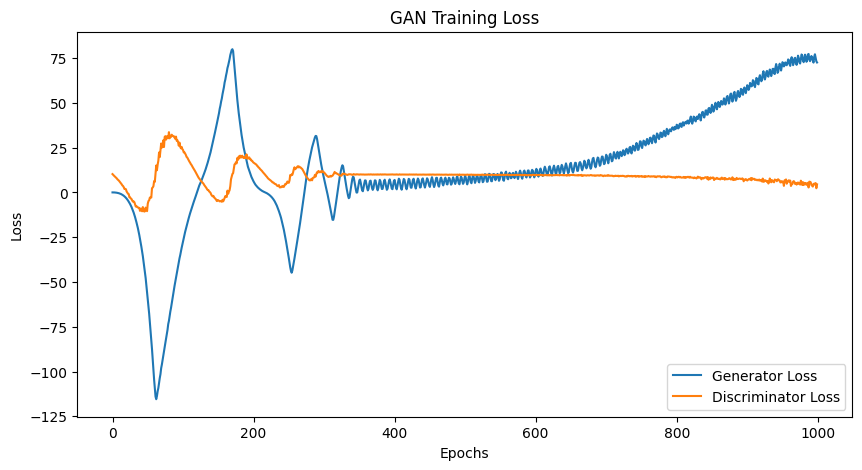

In [9]:
# --------------------
# ✅ Plot Training Loss
# --------------------
def plot_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label='Generator Loss')
    plt.plot(losses_D, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Training Loss')
    plt.show()
plot_losses()

In [10]:
# --------------------
# ✅ Diversity Check
# --------------------
def calculate_diversity(samples):
    distances = pdist(samples, metric="jaccard")
    return np.mean(distances)

def diversity_check():
    z = torch.randn(1000, 128)
    generated_samples = generator(z, edge_index=None).detach().numpy()
    diversity_score = calculate_diversity(generated_samples)
    plt.figure(figsize=(6, 4))
    plt.bar(['Diversity Score'], [diversity_score])
    plt.ylim(0, 1)
    plt.title('GAN Diversity Check')
    plt.show()
diversity_check()

ValueError: `MessagePassing.propagate` only supports integer tensors of shape `[2, num_messages]`, `torch_sparse.SparseTensor` or `torch.sparse.Tensor` for argument `edge_index`.

In [ ]:
# --------------------
# ✅ Molecule Validation and Visualization
# --------------------
def validate_and_visualize_generated_molecules(generator, num_samples=10):
    z = torch.randn(num_samples, 128)
    generated_graphs = generator(z, edge_index=None).detach().numpy()
    valid_molecules = []
    for graph in generated_graphs:
        mol = Chem.RWMol()
        for atom_num in graph:
            mol.AddAtom(Chem.Atom(int(atom_num.item())))
        try:
            smiles = Chem.MolToSmiles(mol)
            if Chem.MolFromSmiles(smiles) is not None:
                valid_molecules.append(Chem.MolFromSmiles(smiles))
        except:
            continue
    if valid_molecules:
        img = Draw.MolsToGridImage(valid_molecules, molsPerRow=5, subImgSize=(200, 200))
        img.show()
    print(f"✅ Valid Molecules Generated: {len(valid_molecules)} / {num_samples}")

validate_and_visualize_generated_molecules(generator)